# Customer Lifetime Value (CLTV) Analysis

## Objective
To calculate customer lifetime value and identify high-value customers using historical transaction data.

## Dataset Loading

In [2]:
import pandas as pd
df = pd.read_csv("../data/cleaned/cleaned_retail_day3.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Revenue Analysis

In [3]:
df["Sales"] = df["Quantity"] * df["UnitPrice"]

In [4]:
customer_revenue = ( df.groupby("CustomerID")["Sales"].sum().sort_values(ascending=False))

customer_revenue.head()

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
Name: Sales, dtype: float64

## Average Order Value (AOV)

In [5]:
aov = (df.groupby("InvoiceNo")["Sales"].sum().mean())

print("Average Order Value:", aov)

Average Order Value: 479.56016047917126


## Purchase Frequency Analysis

In [6]:
purchase_frequency = (df.groupby("CustomerID")["InvoiceNo"].nunique().mean())

print("Purchase Frequency:", purchase_frequency)

Purchase Frequency: 4.272014753342554


## Customer Lifetime Value Calculation

In [7]:
cltv = aov * purchase_frequency

print("Customer Lifetime Value:", cltv)

Customer Lifetime Value: 2048.6880806823424


## Customer Segment Distribution

In [8]:
customer_revenue.describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: Sales, dtype: float64

## Revenue-Based Customer Segmentation

In [9]:
q1 = customer_revenue.quantile(0.25)
q3 = customer_revenue.quantile(0.75)

def segment_customer(x):
    if x >= q3:
        return "High Value"
    elif x >= q1:
        return "Medium Value"
    else:
        return "Low Value"

customer_segments = customer_revenue.reset_index()
customer_segments.columns = ["CustomerID","Revenue"]

customer_segments["Segment"] = customer_segments["Revenue"].apply(segment_customer)

customer_segments["Segment"].value_counts()

Segment
Medium Value    2168
High Value      1085
Low Value       1085
Name: count, dtype: int64

### Customer Segment Distribution

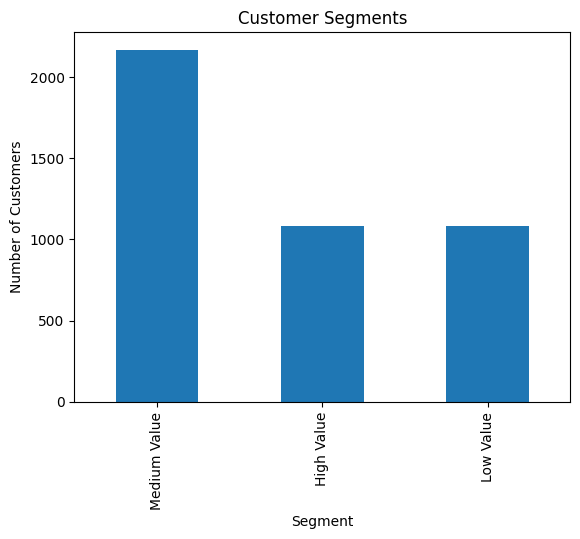

In [10]:
import matplotlib.pyplot as plt

customer_segments["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

## Customer Segmentation Insights

1. Customers have been grouped into High Value, Medium Value, and Low Value segments.

2. High Value customers contribute a disproportionately large share of revenue.

3. Retaining High Value customers should be a priority.

4. Medium Value customers present opportunities for growth through targeted marketing.

5. Low Value customers may require engagement strategies to increase purchase frequency.

## Top Customers by Revenue

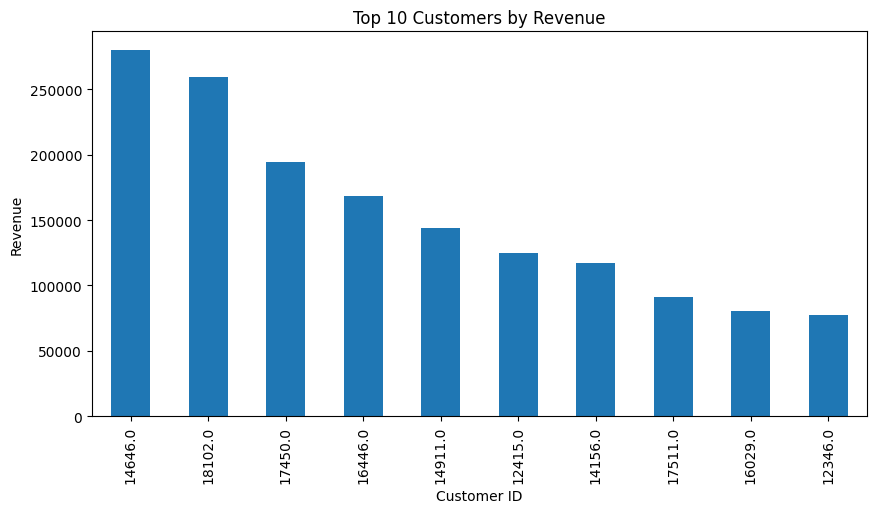

In [11]:
import matplotlib.pyplot as plt

top_customers = customer_revenue.head(10)

plt.figure(figsize=(10,5))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

## Customer Revenue Distribution

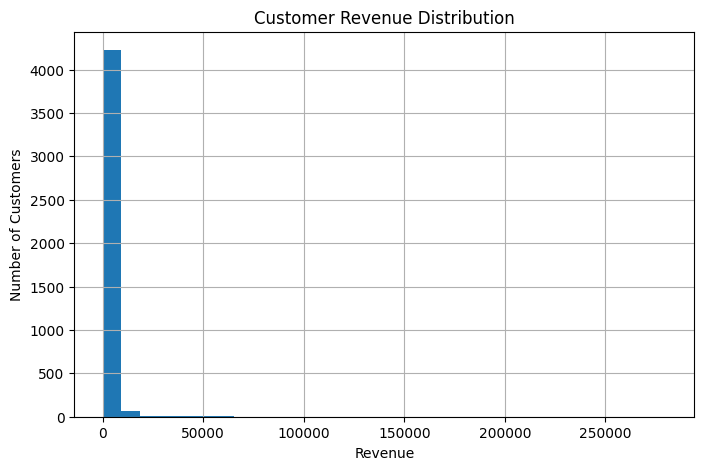

In [12]:
plt.figure(figsize=(8,5))

customer_revenue.hist(bins=30)

plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Customers")
plt.show()

## Customer Purchase Frequency Distribution

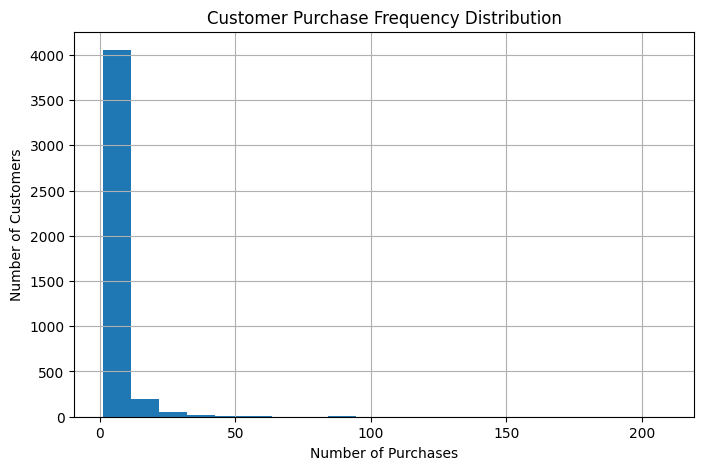

In [13]:
customer_frequency = (df.groupby("CustomerID")["InvoiceNo"].nunique())

plt.figure(figsize=(8,5))

customer_frequency.hist(bins=20)

plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

## CLTV Analysis Insights

1. A small number of customers contribute a significant portion of total revenue.

2. Most customers generate relatively low revenue compared to top-performing customers.

3. Customer purchase frequency varies significantly across the customer base.

4. High-frequency customers contribute more to overall customer lifetime value.

5. Retaining high-value customers can have a substantial impact on business revenue.

## Business Recommendations

1. Focus on retaining high-value customers through loyalty programs.

2. Create personalized marketing campaigns for repeat customers.

3. Monitor customer lifetime value regularly to identify valuable customer segments.

4. Encourage repeat purchases through targeted promotions and discounts.

5. Develop customer engagement strategies to increase purchase frequency.

## Conclusion

The CLTV analysis shows that a small group of customers contributes a significant share of total revenue. Customer purchase frequency and revenue contribution vary considerably across the customer base. By focusing on customer retention and increasing purchase frequency, businesses can improve customer lifetime value and long-term profitability.



# Customer-Level RFM Analysis

Instead of using overall averages, we calculate customer-level
Recency, Frequency and Monetary (RFM).

This forms the foundation for customer segmentation and
segment-wise CLTV analysis.

## Snapshot Date

A reference date is required to calculate customer recency. The snapshot date is defined as one day after the latest transaction in the dataset. This ensures that every customer's most recent purchase can be measured consistently in terms of the number of days since their last transaction.


In [17]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date


Timestamp('2011-12-10 12:50:00')

In [26]:
rfm = (
df.groupby("CustomerID")
      .agg({
          "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
          "InvoiceNo": "nunique",
          "Sales": "sum",
          "Country": "first" })
)

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "Country"
]

rfm.head()

,Recency,Frequency,Monetary,Country
CustomerID,,,,
12346.0,326,1,77183.60,United Kingdom
12347.0,2,7,4310.00,Iceland
12348.0,75,4,1797.24,Finland
12349.0,19,1,1757.55,Italy
12350.0,310,1,334.40,Norway


In [19]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


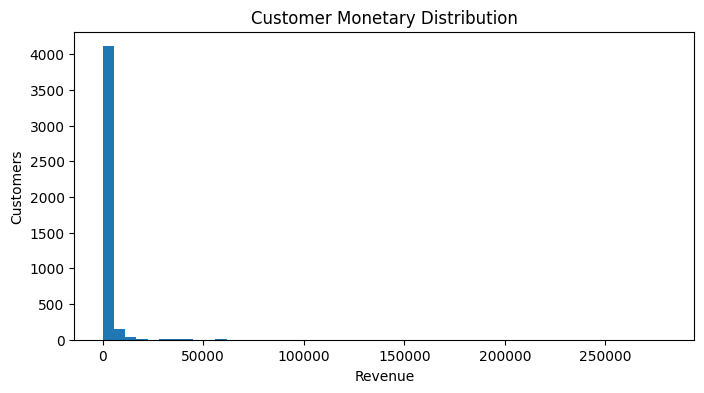

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(rfm["Monetary"], bins=50)

plt.title("Customer Monetary Distribution")
plt.xlabel("Revenue")
plt.ylabel("Customers")

plt.show()

In [21]:
rfm.sort_values(by="Monetary",ascending=False).head(10)

,Recency,Frequency,Monetary,Country
CustomerID,,,,
14646.0,2,73,280206.02,Netherlands
18102.0,1,60,259657.30,United Kingdom
17450.0,8,46,194390.79,United Kingdom
16446.0,1,2,168472.50,United Kingdom
14911.0,1,201,143711.17,EIRE
12415.0,24,21,124914.53,Australia
14156.0,10,55,117210.08,EIRE
17511.0,3,31,91062.38,United Kingdom
16029.0,39,63,80850.84,United Kingdom


In [22]:
rfm[["Recency","Frequency","Monetary"]].corr()

,Recency,Frequency,Monetary
Recency,1.000000,-0.260578,-0.121831
Frequency,-0.260578,1.000000,0.552780
Monetary,-0.121831,0.552780,1.000000


## Key Insights

* Customer purchasing behaviour varies considerably across the customer base.
* Revenue is concentrated among a relatively small group of high-value customers.
* Purchase frequency differs significantly between customers, indicating varying levels of engagement.
* The RFM table establishes a customer-level foundation for advanced analyses such as segment-wise CLTV, customer segmentation, churn analysis, and retention strategies.
